### **Naveed Anjum (Reg # 577607)**
##### Sep 23, 2026
---
## **Tutorial 2: MLP Classifier**

## Step 1 — Importing Required Libraries

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler  # Import StandardScaler for scaling
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt  # Import for plotting the learning curve

## Step 2: Loading and Splitting the Dataset

In [2]:
# Load the Iris dataset
iris = load_iris()
X = iris.data   # Features
y = iris.target  # Labels

# Split the data into training and testing sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Step 3 — Data Scaling

In [3]:
# Standardize the features to have mean=0 and variance=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data and transform
X_test_scaled = scaler.transform(X_test)         # Transform test data (using same scaling)

## Step 4 — Creating and Training the MLP Classifier

In [4]:
# Create an MLP classifier with two hidden layers of 10 neurons each
mlp = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42, learning_rate_init=0.001)

# Train the MLP classifier on the scaled training data
_ = mlp.fit(X_train_scaled, y_train)

## Step 5: Making Predictions and Evaluating the Model

In [5]:
# Predict the test set results
y_pred = mlp.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Print detailed classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.00
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



## Step 6: Displaying the MLP Structure and Training Information

In [6]:
# Display the structure of the MLP classifier
print("\nMLP Structure:")
print(f"Number of layers: {mlp.n_layers_}")
print(f"Number of outputs: {mlp.n_outputs_}")
print(f"Activation function: {mlp.activation}")
print(f"Output activation function: {mlp.out_activation_}")
print(f"Number of epochs: {mlp.n_iter_}")


MLP Structure:
Number of layers: 4
Number of outputs: 3
Activation function: relu
Output activation function: softmax
Number of epochs: 609


## Step 7: Visualizing the Learning Curve

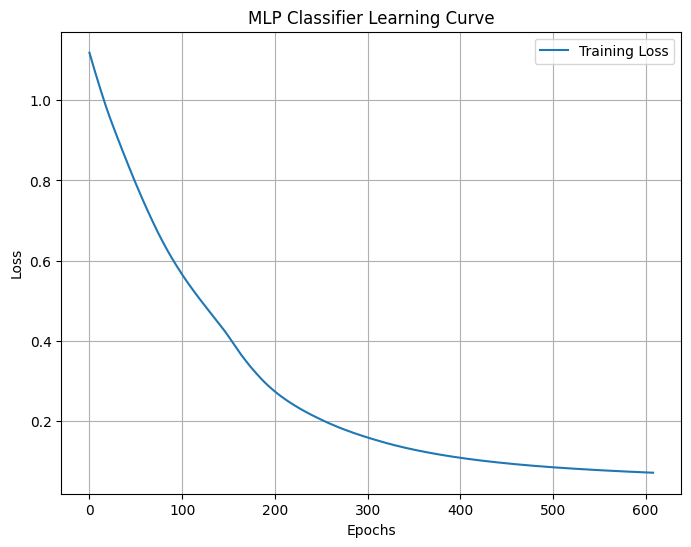

In [7]:
# Plot the loss curve
plt.figure(figsize=(8, 6))
plt.plot(mlp.loss_curve_, label='Training Loss')
plt.title('MLP Classifier Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

---

## Tasks

### Task 1: Modify the MLP model to have different numbers of hidden layers and neurons
**How does increasing the number of layers or neurons affect the accuracy and learning curve?**

Increasing number of layers and neurons improve performance and convergence time/epochs

**What configuration gives the best performance?**

Model with (32,64) coverges in 478 epochs while giving best performance (classification reports parameters)

In [8]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)

Configuration | Accuracy | Epochs
---------------------------------------------
(8,)                 | 0.9778   | 1000
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45

(16,)                | 0.9778   | 741
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45

(16, 32)             | 1.0000   |

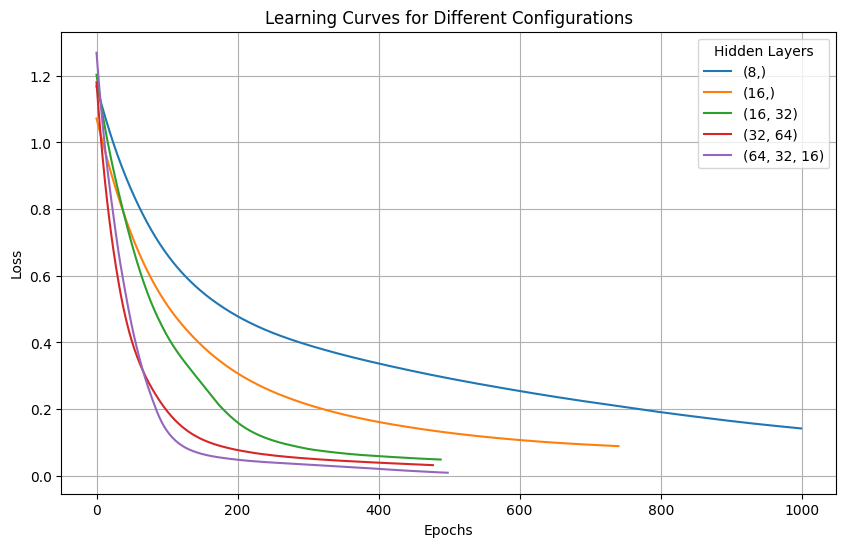

In [9]:
from sklearn.metrics import confusion_matrix # Import for confusion matrix calculation

BLUE = '\033[94m'
END  = '\033[0m'

# Task 1: Experiment with different hidden layer configurations
configurations = [
    (8,),          # 1 hidden layer
    (16,),          # 1 hidden layer
    (16, 32),       # 2 hidden layers
    (32, 64),       # 2 hidden layers
    (64, 32, 16),   # 3 hidden layers
]

print("Configuration | Accuracy | Epochs")
print("-" * 45)

# Create a figure for learning curves
plt.figure(figsize=(10, 6))

for config in configurations:
    model = MLPClassifier(hidden_layer_sizes=config, max_iter=1000, random_state=42, learning_rate_init=0.001)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(BLUE + f"{str(config):20s} | {acc:.4f}   | {model.n_iter_}" + END)
    print("Classification Report:\n", classification_report(y_test, y_pred))
    plt.plot(model.loss_curve_, label=str(config))

    # Calculate and print confusion matrix
    # cm = confusion_matrix(y_test, y_pred)
    # print(f"Confusion Matrix for {config}:\n{cm}\n")

# Show learning curve plot
plt.title('Learning Curves for Different Configurations')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(title='Hidden Layers')
plt.grid()
plt.show()

### Task 2: Change the learning rate and observe its effect on convergence
**How does changing the learning rate affect the loss curve and the number of epochs?**

changes learning rate changes convergence pattern.

**What learning rate provides the best balance between convergence speed and model performance?**

Learning rate of 0.001 gives best performace i.e. early convergence without overfitting.

Learning Rate | Accuracy | Epochs
----------------------------------------
0.0001         | 1.0000   | 1000
0.001          | 1.0000   | 478
0.01           | 0.9778   | 174
0.1            | 0.9778   | 140


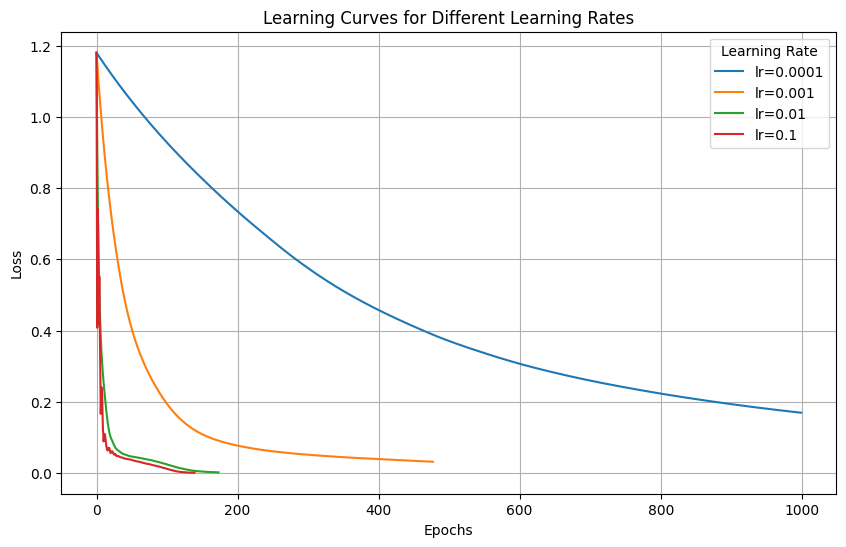

In [15]:
# Task 2: Experiment with different learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1]

print("Learning Rate | Accuracy | Epochs")
print("-" * 40)

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    model = MLPClassifier(hidden_layer_sizes=(32, 64), max_iter=1000, random_state=42, learning_rate_init=lr)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"{lr:<14} | {acc:.4f}   | {model.n_iter_}")
    plt.plot(model.loss_curve_, label=f'lr={lr}')

plt.title('Learning Curves for Different Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(title='Learning Rate')
plt.grid()
plt.show()